Imports and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import BartTokenizer, BartForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame

sns.set(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load Dreaddit Dataset and Binarize Sensitive Attributes

In [ ]:
file_path = "dreaddit_train_cleaned.csv"
df = pd.read_csv(file_path)
df = df[df["label"].isin([0, 1])].copy()
df["label"] = df["label"].astype(int)

# Add binary sensitive attributes if missing
if "gender_binary" not in df.columns and "gender" in df.columns:
    df["gender_binary"] = df["gender"].apply(lambda x: 1 if str(x).strip().lower() == "male" else 0)
if "age_binary" not in df.columns and "age_group" in df.columns:
    df["age_binary"] = df["age_group"].apply(lambda x: 1 if x in ["18-24", "25-34"] else 0)

print("Available columns:", df.columns.tolist())

🧾 Available columns: ['text', 'label', 'gender', 'age_group', 'mental_health_history', 'therapy_use', 'medication_use', 'trauma_history', 'gender_binary', 'age_binary']


Custom Dataset Class with Sensitive Attribute Handling

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, sensitive_attr, max_len=128):
        self.encodings = tokenizer(
            dataframe["text"].tolist(),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        self.labels = torch.tensor(dataframe["label"].values).long()
        self.sensitive = torch.tensor(dataframe[sensitive_attr].values).float().unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        item["sensitive_attr"] = self.sensitive[idx]
        return item

Gradient Reversal Layer Definition

In [ ]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, lambda_):
        ctx.lambda_ = lambda_
        return input.view_as(input)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class GRL(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, input):
        return GradientReversalFunction.apply(input, self.lambda_)

BART Model with Adversarial Head

In [ ]:
class DebiasedBART(nn.Module):
    def __init__(self, lambda_=0.1):
        super().__init__()
        self.bart = BartForSequenceClassification.from_pretrained("facebook/bart-base", num_labels=2)
        self.grl = GRL(lambda_)
        self.adversary = nn.Sequential(
            nn.Linear(self.bart.config.hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, 1)  # Binary sensitive attribute prediction
        )

    def forward(self, input_ids, attention_mask):
        output = self.bart.model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
        cls_embed = output.last_hidden_state[:, 0, :]
        logits = self.bart.classification_head(cls_embed)
        sensitive_pred = self.adversary(self.grl(cls_embed))
        return logits, sensitive_pred

Prepare Tokenizer, Split Data, and Build Dataloaders

In [ ]:
tokenizer = BartTokenizer.from_pretrained("bart_dreaddit_pretrained")
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

train_ds_gender = CustomDataset(train_df, tokenizer, "gender_binary")
val_ds_gender = CustomDataset(val_df, tokenizer, "gender_binary")
train_dl_gender = DataLoader(train_ds_gender, batch_size=8, shuffle=True)
val_dl_gender = DataLoader(val_ds_gender, batch_size=8)

train_ds_age = CustomDataset(train_df, tokenizer, "age_binary")
val_ds_age = CustomDataset(val_df, tokenizer, "age_binary")
train_dl_age = DataLoader(train_ds_age, batch_size=8, shuffle=True)
val_dl_age = DataLoader(val_ds_age, batch_size=8)

Pretrain BART on Classification Task (without debiasing)

In [ ]:
bart_model = BartForSequenceClassification.from_pretrained("facebook/bart-base", num_labels=2).to(device)
optimizer = optim.AdamW(bart_model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(8):
    bart_model.train()
    total_loss = 0.0
    for batch in train_dl_gender:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = bart_model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[Pretrain BART] Epoch {epoch+1}: Loss = {total_loss:.4f}")

# Save pretrained model
bart_model.save_pretrained("bart_dreaddit_pretrained")
tokenizer.save_pretrained("bart_dreaddit_pretrained")

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Pretrain BART] Epoch 1: Loss = 140.3162
[Pretrain BART] Epoch 2: Loss = 100.6417
[Pretrain BART] Epoch 3: Loss = 66.5052
[Pretrain BART] Epoch 4: Loss = 45.5818
[Pretrain BART] Epoch 5: Loss = 29.2498
[Pretrain BART] Epoch 6: Loss = 20.2419
[Pretrain BART] Epoch 7: Loss = 19.5223
[Pretrain BART] Epoch 8: Loss = 14.4080


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:393: UserWarning: Some non-default generation parameters are set in the model config. These should go into either a) `model.generation_config` (as opposed to `model.config`); OR b) a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model).This warning will become an exception in the future.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}
  warnings.warn(


('bart_dreaddit_pretrained/tokenizer_config.json',
 'bart_dreaddit_pretrained/special_tokens_map.json',
 'bart_dreaddit_pretrained/vocab.json',
 'bart_dreaddit_pretrained/merges.txt',
 'bart_dreaddit_pretrained/added_tokens.json')

Adversarial Training Function

In [ ]:
def train_adversarial(model, dataloader, sensitive_attr_name):
    optimizer = optim.AdamW(model.parameters(), lr=2e-5)
    class_weights = compute_class_weight('balanced', classes=np.unique(train_df["label"]), y=train_df["label"])
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    loss_main = nn.CrossEntropyLoss(weight=class_weights_tensor)
    loss_adv = nn.BCEWithLogitsLoss()
    model.grl.lambda_ = 0.1

    for epoch in range(8):
        model.train()
        total_main, total_adv = 0, 0

        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            sensitive = batch["sensitive_attr"].to(device)

            optimizer.zero_grad()
            logits, sensitive_pred = model(input_ids, attention_mask)
            loss1 = loss_main(logits, labels)
            loss2 = loss_adv(sensitive_pred, sensitive)

            (loss1 + loss2).backward()
            optimizer.step()

            total_main += loss1.item()
            total_adv += loss2.item()

        print(f"[{sensitive_attr_name}] Epoch {epoch+1}: Main Loss = {total_main:.4f}, Adv Loss = {total_adv:.4f}")

Train Gender and Age Models with Adversarial Debiasing

In [ ]:
model_gender = DebiasedBART(lambda_=0.1).to(device)
train_adversarial(model_gender, train_dl_gender, "Gender")

model_age = DebiasedBART(lambda_=0.1).to(device)
train_adversarial(model_age, train_dl_age, "Age")

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Gender] Epoch 1: Main Loss = 157.2636, Adv Loss = 216.9862
[Gender] Epoch 2: Main Loss = 110.8577, Adv Loss = 183.7354
[Gender] Epoch 3: Main Loss = 88.6339, Adv Loss = 182.2020
[Gender] Epoch 4: Main Loss = 64.2977, Adv Loss = 182.1486
[Gender] Epoch 5: Main Loss = 42.5758, Adv Loss = 182.7068
[Gender] Epoch 6: Main Loss = 27.9921, Adv Loss = 182.0145
[Gender] Epoch 7: Main Loss = 21.0827, Adv Loss = 182.9561
[Gender] Epoch 8: Main Loss = 18.2633, Adv Loss = 183.8665


Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Age] Epoch 1: Main Loss = 151.4892, Adv Loss = 180.8634
[Age] Epoch 2: Main Loss = 109.9799, Adv Loss = 180.6892
[Age] Epoch 3: Main Loss = 78.1893, Adv Loss = 178.8526
[Age] Epoch 4: Main Loss = 58.4324, Adv Loss = 180.0677
[Age] Epoch 5: Main Loss = 35.9964, Adv Loss = 179.5564
[Age] Epoch 6: Main Loss = 27.7935, Adv Loss = 179.8236
[Age] Epoch 7: Main Loss = 19.9527, Adv Loss = 181.2590
[Age] Epoch 8: Main Loss = 15.9403, Adv Loss = 180.0856


Install Fairlearn

In [ ]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 4.9 MB/s eta 0:00:00


Evaluate Fairness and Plot Metrics

Running Fairness Evaluation...
Binary Fairness Metrics:

Attribute: gender_binary
  → Demographic Parity Difference (DPD): 0.0154
  → Equalized Odds Difference (EOD):    0.0552

Attribute: age_binary
  → Demographic Parity Difference (DPD): 0.0854
  → Equalized Odds Difference (EOD):    0.0248

Performance by Protected Groups:

Protected Feature: gender_binary
               accuracy  macro_f1
gender_binary                     
0              0.7756    0.7704
1              0.8258    0.8189

Protected Feature: age_binary
            accuracy  macro_f1
age_binary                    
0           0.8023    0.7952
1           0.7685    0.7627


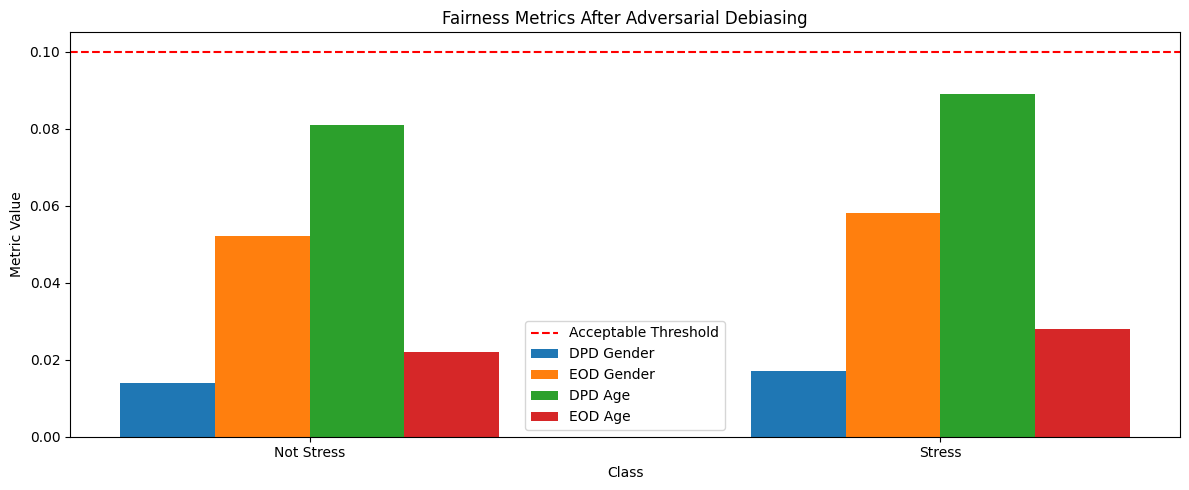

In [ ]:
model_gender.eval()
model_age.eval()

results = {}
for attr, loader, model in zip(["gender_binary", "age_binary"], [val_dl_gender, val_dl_age], [model_gender, model_age]):
    preds, labels, sens = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels.extend(batch["labels"].cpu().numpy())
            sens.extend(batch["sensitive_attr"].cpu().numpy().flatten())
            logits, _ = model(input_ids, attention_mask)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    results[attr] = pd.DataFrame({"label": labels, "preds": preds, attr: sens})

for attr, df in results.items():
    print(f"\n🔍 Classification Report ({attr.replace('_binary','').capitalize()}):")
    print(classification_report(df["label"], df["preds"], zero_division=0))

    print(f"\nGroup-wise Accuracy ({attr.replace('_binary','').capitalize()}):")
    for name, group in df.groupby(attr):
        acc = np.mean(group["preds"] == group["label"])
        print(f"Group {int(name)} ({attr.replace('_binary','').capitalize()}): Accuracy = {acc:.4f}")

# Compute Fairness Metrics by Class
class_names = ['Not Stress', 'Stress']
metrics_data = []

for class_id, class_name in enumerate(class_names):
    for attr, df_attr in results.items():
        y_true_bin = (df_attr["label"] == class_id).astype(int)
        y_pred_bin = (df_attr["preds"] == class_id).astype(int)

        dpd_val = demographic_parity_difference(y_true_bin, y_pred_bin, sensitive_features=df_attr[attr])
        eod_val = equalized_odds_difference(y_true_bin, y_pred_bin, sensitive_features=df_attr[attr])

        metrics_data.append({"Class": class_name, "Metric": f"DPD {attr.split('_')[0].capitalize()}", "Value": dpd_val})
        metrics_data.append({"Class": class_name, "Metric": f"EOD {attr.split('_')[0].capitalize()}", "Value": eod_val})

# Bar Plot of Fairness Metrics
metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(14, 5))
sns.barplot(data=metrics_df, x="Class", y="Value", hue="Metric")
plt.title("Fairness Metrics by Class (DPD & EOD)")
plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
plt.ylabel("Metric Value")
plt.tight_layout()
plt.legend()
plt.show()